In [1]:
# ============================================================
# Imports
# ============================================================

import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysindy as ps

from IPython.display import display


In [2]:
# ============================================================
# Shared OU parameters and helper functions
# ============================================================

kappa = 1.0
D = 1.0

# Non-stationary Gaussian initial distribution
m0 = -2.0
s0 = 0.5

# Space-time domain
x_L = -5.0
x_R = 5.0
T_final = 3.0


def exact_ou_moments(t_grid, kappa, D, m0, s0):
    """Return the exact OU mean, variance and their time derivatives."""

    mean = m0 * np.exp(-kappa * t_grid)

    variance = (
        s0**2 * np.exp(-2.0 * kappa * t_grid)
        + (D / kappa) * (
            1.0 - np.exp(-2.0 * kappa * t_grid)
        )
    )

    mean_t = -kappa * mean
    variance_t = -2.0 * kappa * variance + 2.0 * D

    return mean, variance, mean_t, variance_t


def exact_ou_density(x_grid, t_grid, kappa, D, m0, s0):
    """Exact density of dX_t = -kappa X_t dt + sqrt(2D) dW_t."""

    mean, variance, _, _ = exact_ou_moments(
        t_grid,
        kappa,
        D,
        m0,
        s0,
    )

    return (
        np.exp(
            -0.5 * (x_grid - mean)**2 / variance
        )
        / np.sqrt(2.0 * np.pi * variance)
    )


def exact_ou_time_derivative(x_grid, t_grid, kappa, D, m0, s0):
    """Analytical time derivative of the exact OU density."""

    mean, variance, mean_t, variance_t = exact_ou_moments(
        t_grid,
        kappa,
        D,
        m0,
        s0,
    )

    density = exact_ou_density(
        x_grid,
        t_grid,
        kappa,
        D,
        m0,
        s0,
    )

    return density * (
        mean_t * (x_grid - mean) / variance
        + variance_t
        / (2.0 * variance**2)
        * (
            (x_grid - mean)**2 - variance
        )
    )


def relative_l2_error(approximation, reference):
    """Relative Euclidean L2 error after flattening both arrays."""

    approximation = np.asarray(approximation).ravel()
    reference = np.asarray(reference).ravel()

    reference_norm = np.linalg.norm(reference)

    if reference_norm == 0.0:
        raise ZeroDivisionError(
            "The reference array has zero L2 norm."
        )

    return (
        np.linalg.norm(approximation - reference)
        / reference_norm
    )


def print_identified_equation(feature_names, coefficients, tolerance=1e-10):
    """Print a readable sparse PDE from identified coefficients."""

    identified_terms = []

    for name, coefficient in zip(feature_names, coefficients):
        if abs(coefficient) > tolerance:
            identified_terms.append(
                f"({coefficient:+.6f}) {name}"
            )

    equation = " ".join(identified_terms)

    print("True Fokker–Planck equation:")
    print(
        f"rho_t = {kappa:.6f} d_x(x rho)"
        f" + {D:.6f} rho_xx"
    )

    print()
    print("Identified Fokker–Planck equation:")
    print(f"rho_t = {equation}")


def plot_error_heatmap(t_grid, x_grid, error_field, title, colorbar_label="Error"):
    """Plot a signed error field with symmetric colour limits."""

    max_abs_error = np.max(np.abs(error_field))
    max_abs_error = max(max_abs_error, np.finfo(float).eps)

    fig, ax = plt.subplots(figsize=(8, 5))

    plot = ax.pcolormesh(
        t_grid,
        x_grid,
        error_field,
        shading="auto",
        vmin=-max_abs_error,
        vmax=max_abs_error,
        cmap="coolwarm",
    )

    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$x$")
    ax.set_title(title)

    fig.colorbar(
        plot,
        ax=ax,
        label=colorbar_label,
    )

    plt.tight_layout()
    plt.show()


# 1. Exact OU density

Here the input density is analytical, but the SINDy target is still obtained by numerical differentiation:

$$
\rho^{\mathrm{exact}}
\xrightarrow{\text{numerical }\partial_t}
\rho_t
\xrightarrow{\text{SINDy}}
\widehat{\rho_t}.
$$

The analytical derivative $\rho_t^{\mathrm{exact}}$ is retained separately as the validation reference.


In [3]:
# ============================================================
# 1.1 Exact-data space-time grid
# ============================================================

Nx_exact = 400
Nt_exact = 600

x = np.linspace(x_L, x_R, Nx_exact + 1)
t = np.linspace(0.0, T_final, Nt_exact + 1)

dx = x[1] - x[0]
dt = t[1] - t[0]

# X[i, j] = x[i], Time[i, j] = t[j]
X, Time = np.meshgrid(
    x,
    t,
    indexing="ij",
)

print("x shape:   ", x.shape)
print("t shape:   ", t.shape)
print("grid shape:", X.shape)
print("dx:        ", dx)
print("dt:        ", dt)


x shape:    (401,)
t shape:    (601,)
grid shape: (401, 601)
dx:         0.025000000000000355
dt:         0.005


In [4]:
# ============================================================
# 1.2 Analytical density and analytical time derivative
# ============================================================

rho_exact = exact_ou_density(
    X,
    Time,
    kappa,
    D,
    m0,
    s0,
)

# Ground truth used for validation only
rho_t_exact = exact_ou_time_derivative(
    X,
    Time,
    kappa,
    D,
    m0,
    s0,
)

print("rho_exact shape: ", rho_exact.shape)
print("rho_t_exact shape:", rho_t_exact.shape)


rho_exact shape:  (401, 601)
rho_t_exact shape: (401, 601)


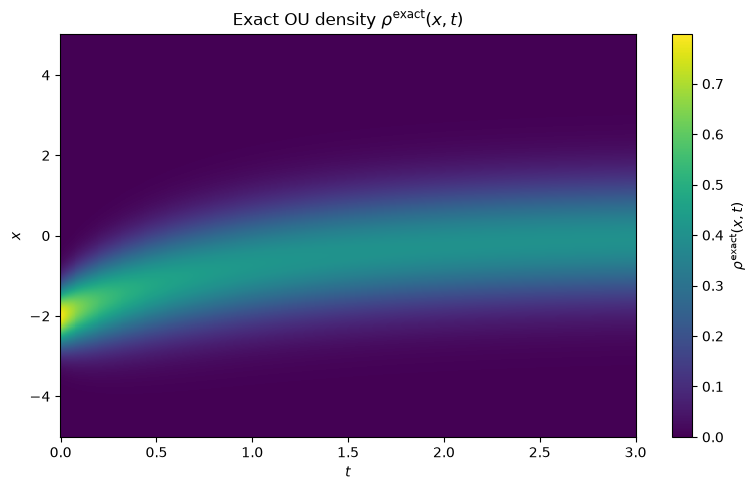

In [5]:
# ============================================================
# 1.3 Visualise the exact density data
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

plot = ax.pcolormesh(
    t,
    x,
    rho_exact,
    shading="auto",
)

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$x$")
ax.set_title(
    r"Exact OU density $\rho^{\mathrm{exact}}(x,t)$"
)

fig.colorbar(
    plot,
    ax=ax,
    label=r"$\rho^{\mathrm{exact}}(x,t)$",
)

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 1.4 Numerical derivatives computed from rho_exact
# ============================================================

Dt_exact_data = ps.FiniteDifference(
    d=1,
    axis=1,
    order=4,
)

Dx_exact_data = ps.FiniteDifference(
    d=1,
    axis=0,
    order=4,
)

Dxx_exact_data = ps.FiniteDifference(
    d=2,
    axis=0,
    order=4,
)

Dxxx_exact_data = ps.FiniteDifference(
    d=3,
    axis=0,
    order=4,
)

# Numerical time derivative used as the SINDy target
rho_t = Dt_exact_data(rho_exact, t)

# Numerical spatial derivatives used to construct the library
rho_x = Dx_exact_data(rho_exact, x)
rho_xx = Dxx_exact_data(rho_exact, x)
rho_xxx = Dxxx_exact_data(rho_exact, x)
rho_square_x = Dx_exact_data(rho_exact**2, x)
rho_cubic_x = Dx_exact_data(rho_exact**3, x)
rho_square_xx = Dxx_exact_data(rho_exact**2, x)
rho_cubic_xx = Dxx_exact_data(rho_exact**3, x)
rho_square_xxx = Dxxx_exact_data(rho_exact**2, x)
rho_cubic_xxx = Dxxx_exact_data(rho_exact**3, x)

# Conservative drift candidates
d_x_xrho = Dx_exact_data(X * rho_exact, x)
d_x_x2rho = Dx_exact_data(X**2 * rho_exact, x)
d_x_x3rho = Dx_exact_data(X**3 * rho_exact, x)



print("rho_t shape:", rho_t.shape)


rho_t shape: (401, 601)


In [7]:
# ============================================================
# 1.5 Candidate library for exact-density data
# ============================================================

candidate_fields = {
    "rho": rho_exact,
    
    "rho_x": rho_x,
    "d_x(rho^2)": rho_square_x,
    "d_x(rho^3)": rho_cubic_x,

    "d_x(x rho)": d_x_xrho,
    "d_x(x^2 rho)": d_x_x2rho,
    "d_x(x^3 rho)": d_x_x3rho,
    
    "rho_xx": rho_xx,
    "d_xx(rho^2)": rho_square_xx,
    "d_xx(rho^3)": rho_cubic_xx,
    
    "rho_xxx": rho_xxx,
    "d_xxx(rho^2)": rho_square_xxx,
    "d_xxx(rho^3)": rho_cubic_xxx,
}

feature_names = list(candidate_fields.keys())

true_coefficients = np.array([
    0.0,       # rho
    0.0,       # rho_square_x
    0.0,       # rho_cubic_x
    0.0,       # rho_x
    kappa,     # d_x(x rho)
    0.0,       # d_x(x^2 rho)
    0.0,       # d_x(x^3 rho)
    D,         # rho_xx
    0.0,       # rho_square_xx
    0.0,       # rho_square_xx
    0.0,       # rho_xxx
    0.0,       # rho_square_xxx
    0.0,       # rho_cubic_xxx
])

print("Candidate terms:")
for name in feature_names:
    print("  ", name)


Candidate terms:
   rho
   rho_x
   d_x(rho^2)
   d_x(rho^3)
   d_x(x * rho)
   d_x(x^2* rho)
   d_x(x^3 *rho)
   rho_xx
   d_xx(rho^2)
   d_xx(rho^3)
   rho_xxx
   d_xxx(rho^2)
   d_xxx(rho^3)


In [8]:
# ============================================================
# 1.6 Interior fitting region and sparse regression
# ============================================================

# Fourth-order finite differences require boundary care.
# These slices are used consistently for fitting and all errors.
space_slice = slice(4, -4)
time_slice = slice(2, -2)

Theta = np.column_stack([
    field[space_slice, time_slice].ravel()
    for field in candidate_fields.values()
])

rho_t_vector = rho_t[
    space_slice,
    time_slice,
].ravel().reshape(-1, 1)

optimizer_exact = ps.STLSQ(
    threshold=0.1,
    alpha=1e-10,
    max_iter=50,
    normalize_columns=True,
)

optimizer_exact.fit(
    Theta,
    rho_t_vector,
)

coefficients = optimizer_exact.coef_.reshape(-1)

print("Theta shape:      ", Theta.shape)
print("rho_t target shape:", rho_t_vector.shape)


Theta shape:       (234621, 13)
rho_t target shape: (234621, 1)


In [9]:
# ============================================================
# 1.7 Identified coefficients and PDE
# ============================================================

coefficient_table = pd.DataFrame({
    "Candidate term": feature_names,
    "Identified coefficient": coefficients,
    "True coefficient": true_coefficients,
    "Absolute error": np.abs(
        coefficients - true_coefficients
    ),
})

display(
    coefficient_table.style.format({
        "Identified coefficient": "{:.6f}",
        "True coefficient": "{:.6f}",
        "Absolute error": "{:.3e}",
    }).set_caption("SINDy coefficients from Exact density")
)

print_identified_equation(
    feature_names,
    coefficients,
)


,Candidate term,Identified coefficient,True coefficient,Absolute error
0,rho,0.000000,0.000000,0.000e+00
1,rho_x,0.000000,0.000000,0.000e+00
2,d_x(rho^2),0.000000,0.000000,0.000e+00
3,d_x(rho^3),0.000000,0.000000,0.000e+00
4,d_x(x * rho),1.000000,1.000000,2.468e-07
5,d_x(x^2* rho),0.000000,0.000000,0.000e+00
6,d_x(x^3 *rho),0.000000,0.000000,0.000e+00
7,rho_xx,1.000000,1.000000,2.066e-07
8,d_xx(rho^2),0.000000,0.000000,0.000e+00
9,d_xx(rho^3),0.000000,0.000000,0.000e+00


True Fokker–Planck equation:
rho_t = 1.000000 d_x(x rho) + 1.000000 rho_xx

Identified Fokker–Planck equation:
rho_t = (+1.000000) d_x(x * rho) (+1.000000) rho_xx


In [10]:
# ============================================================
# 1.8 Reconstruct the identified derivative rho_t_hat
# ============================================================

rho_t_hat = np.zeros_like(rho_t)

for coefficient, field in zip(
    coefficients,
    candidate_fields.values(),
):
    rho_t_hat += coefficient * field

print(r"Constructed rho_t_hat = sum_j coefficient_j * candidate_field_j")
print("rho_t_hat shape:", rho_t_hat.shape)


Constructed rho_t_hat = sum_j coefficient_j * candidate_field_j
rho_t_hat shape: (401, 601)


In [11]:
# ============================================================
# 1.9 Three errors for exact-density identification
# ============================================================

rho_t_interior = rho_t[
    space_slice,
    time_slice,
]

rho_t_exact_interior = rho_t_exact[
    space_slice,
    time_slice,
]

rho_t_hat_interior = rho_t_hat[
    space_slice,
    time_slice,
]

# 1. Numerical differentiation error:
#    rho_t is computed numerically from rho_exact.
error_exact_differentiation = relative_l2_error(
    rho_t_interior,
    rho_t_exact_interior,
)

# 2. SINDy fitting error relative to its actual numerical target.
error_exact_fit = relative_l2_error(
    rho_t_hat_interior,
    rho_t_interior,
)

# 3. End-to-end identification error relative to exact dynamics.
error_exact_total = relative_l2_error(
    rho_t_hat_interior,
    rho_t_exact_interior,
)

exact_error_table = pd.DataFrame({
    "Comparison": [
        "Numerical derivative vs analytical derivative",
        "SINDy derivative vs numerical target",
        "SINDy derivative vs analytical derivative",
    ],
    "Mathematical quantity": [
        r"rho_t - rho_t_exact",
        r"rho_t_hat - rho_t",
        r"rho_t_hat - rho_t_exact",
    ],
    "Relative L2 error": [
        error_exact_differentiation,
        error_exact_fit,
        error_exact_total,
    ],
    "Meaning": [
        "Numerical time-differentiation error",
        "Sparse-regression fitting error",
        "Total identification error",
    ],
})

display(
    exact_error_table.style.format({
        "Relative L2 error": "{:.6e}",
    })
)


,Comparison,Mathematical quantity,Relative L2 error,Meaning
0,Numerical derivative vs analytical derivative,rho_t - rho_t_exact,7.902051e-07,Numerical time-differentiation error
1,SINDy derivative vs numerical target,rho_t_hat - rho_t,6.226625e-07,Sparse-regression fitting error
2,SINDy derivative vs analytical derivative,rho_t_hat - rho_t_exact,5.738601e-07,Total identification error


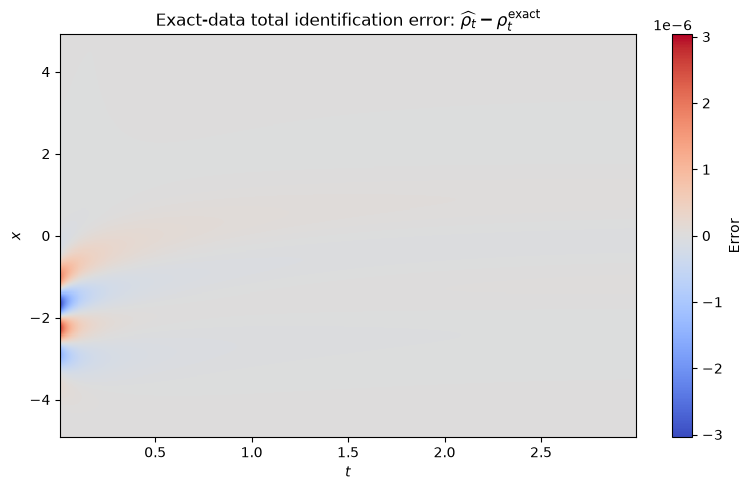

In [12]:
# ============================================================
# 1.10 Exact-data heatmap: total identification error
# ============================================================

# Error convention used throughout:
# prediction minus reference
error_total_exact_field = (
    rho_t_hat_interior
    - rho_t_exact_interior
)

plot_error_heatmap(
    t[time_slice],
    x[space_slice],
    error_total_exact_field,
    title=(
        r"Exact-data total identification error: "
        r"$\widehat{\rho_t}-\rho_t^{\mathrm{exact}}$"
    ),
)
